E-commerce

##Planning

Links

Dataset - https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews$0



Train model

Dummy interface (like amazon)

Model generates useful info on product based off reviews

##Download e-commerce dataset as 'df'

In [ ]:
import kagglehub
import pandas
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Womens Clothing E-Commerce Reviews.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "nicapotato/womens-ecommerce-clothing-reviews",
  file_path,
  pandas_kwargs={'encoding': 'latin1'}
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df_copy = df.copy()
print("First 5 records of the DataFrame:")
display(df_copy.head())


ModuleNotFoundError: No module named 'kagglehub'

## Data Cleaning

In [ ]:
print("Shape:", df.shape)
df.info()


Shape: (23486, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [ ]:
missing = df_copy.isna().sum().sort_values(ascending=False)
missing[missing > 0]
missing_div = df_copy[df_copy['Division Name'].isna()].index
missing_dep = df_copy[df_copy['Department Name'].isna()].index
missing_cl = df_copy[df_copy['Class Name'].isna()].index

print("Division == Department:", missing_div.equals(missing_dep))
print("Department == Class:", missing_dep.equals(missing_cl))

df_copy.loc[missing_div, ['Clothing ID', 'Division Name', 'Department Name', 'Class Name']]

Division == Department: True
Department == Class: True


,Clothing ID,Division Name,Department Name,Class Name
9444,72,NaN,NaN,NaN
13767,492,NaN,NaN,NaN
13768,492,NaN,NaN,NaN
13787,492,NaN,NaN,NaN
16216,152,NaN,NaN,NaN
16221,152,NaN,NaN,NaN
16223,152,NaN,NaN,NaN
18626,184,NaN,NaN,NaN
18671,184,NaN,NaN,NaN
20088,772,NaN,NaN,NaN


In [ ]:
for clothing_id in df_copy.loc[missing_div, 'Clothing ID'].unique():
    same_item = df_copy[df_copy['Clothing ID'] == clothing_id]
    has_info = same_item['Division Name'].notna().any()
    total = len(same_item)
    filled = same_item['Division Name'].notna().sum()

    print(f"Clothing ID {clothing_id}: {filled}/{total} rows have category info — {'✓ can impute' if has_info else '✗ drop'}")

Clothing ID 72: 0/1 rows have category info — ✗ drop
Clothing ID 492: 0/3 rows have category info — ✗ drop
Clothing ID 152: 0/3 rows have category info — ✗ drop
Clothing ID 184: 0/2 rows have category info — ✗ drop
Clothing ID 772: 0/1 rows have category info — ✗ drop
Clothing ID 665: 0/1 rows have category info — ✗ drop
Clothing ID 136: 0/3 rows have category info — ✗ drop


In [ ]:
df_copy = df_copy.drop(index=missing_div)

In [ ]:
print(f"shape after drop: {df_copy.shape}")
print(df_copy[['Division Name', 'Department Name', 'Class Name']].isna().sum())

shape after drop: (23472, 11)
Division Name      0
Department Name    0
Class Name         0
dtype: int64


In [ ]:
missing[missing > 0]

,0
Title,3810
Review Text,845
Department Name,14
Class Name,14
Division Name,14


In [ ]:
df_copy['Title']= df_copy['Title'].fillna('No Title')
df_copy['Review Text'] = df_copy['Review Text'].fillna('No Review')
print(df_copy[['Title', 'Review Text']].isna().sum())


Title          0
Review Text    0
dtype: int64


In [ ]:
missing = df_copy.isna().sum().sort_values(ascending=False)
missing[missing>0]

,0
Title,3810
Review Text,845
Department Name,14
Class Name,14
Division Name,14


##Visualizations



#####Raw Data

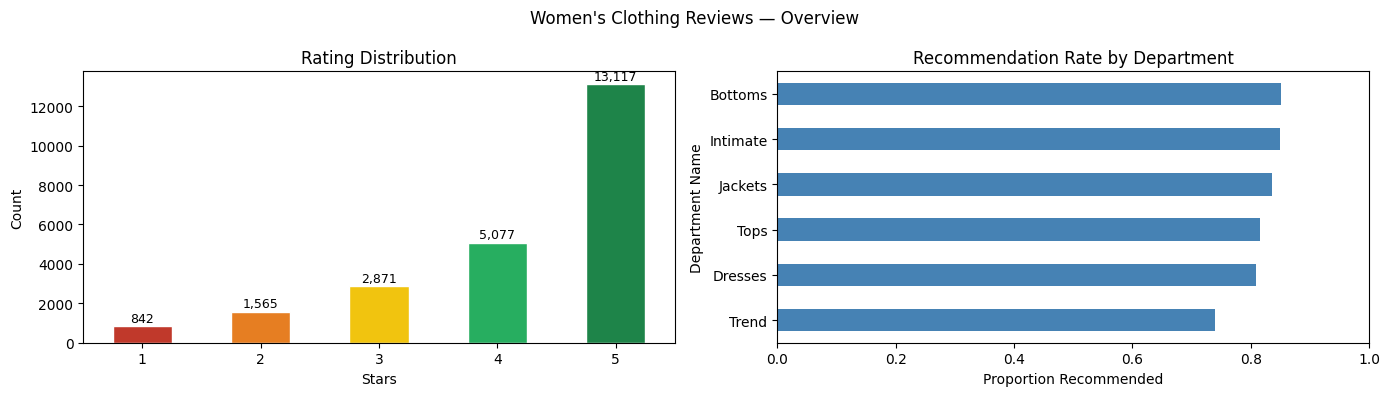

In [ ]:
# ── Visualizations: Raw Data ──────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Women's Clothing Reviews — Overview")

# Plot 1: Rating distribution
df_copy['Rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0],
    color=['#c0392b','#e67e22','#f1c40f','#27ae60','#1e8449'],
    edgecolor='white'
)
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Stars")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=9
    )

# Plot 2: Recommendation rate by department
dept_rec = (df_copy
    .groupby('Department Name')['Recommended IND']
    .mean()
    .sort_values()
)
dept_rec.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title("Recommendation Rate by Department")
axes[1].set_xlabel("Proportion Recommended")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()













































##Preprocessing


In [ ]:
import pandas as pd
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt',     quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r'<.*?>', '', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# drop rows with no review text
df_model = df_copy.dropna(subset=['Review Text']).copy()

# drop 3-star rows
df_model = df_model[df_model['Rating'] != 3]

# create binary label
df_model['label'] = (df_model['Rating'] >= 4).astype(int)

print(f"Total rows: {len(df_model):,}")
print(f"Positive (4-5*)): {(df_model['label'] == 1).sum():,}")
print(f"Negative (1-2*): {(df_model['label'] == 0).sum():,}")

# apply preprocessing — takes ~30 seconds
df_model['clean_review'] = df_model['Review Text'].apply(preprocess_text)

# sanity check
print("\nBEFORE:", df_model['Review Text'].iloc[0][:100])
print("AFTER: ", df_model['clean_review'].iloc[0][:100])

#####Word Clouds

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(df_model[df_model['label'] == 1]['clean_review'])
negative_text = " ".join(df_model[df_model['label'] == 0]['clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(
    WordCloud(width=700, height=400, colormap='Greens',
              max_words=80, background_color='white')
    .generate(positive_text),
    interpolation='bilinear'
)
axes[0].set_title("Most Common Words — Positive Reviews")
axes[0].axis('off')

axes[1].imshow(
    WordCloud(width=700, height=400, colormap='Reds',
              max_words=80, background_color='white')
    .generate(negative_text),
    interpolation='bilinear'
)
axes[1].set_title("Most Common Words — Negative Reviews")
axes[1].axis('off')

plt.tight_layout()
plt.show()

NameError: name 'df_model' is not defined

##Training
